In [1]:
! pip install pandas

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 17.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 3.6 MB/s eta 0:00:0000:0100:01
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [pandas]2m3/4 [pandas]


In [5]:
! pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 16.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 5.9 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 2.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


In [51]:
! pip install numpy
! pip install imbalanced-learn
! pip install scikit-learn
! pip install tensorflow

  Using cached tensorflow-2.19.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.1 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-5.29.5-cp38-abi3-manylinux2014_x86_64.whl.metadata (592 bytes)
  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached wrapt-1.17.2-cp311-cp311-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.4 kB)
  Using cached grpcio-1.73.1-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.meta

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
import sklearn.utils.class_weight as sk_weights
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf


2025-07-06 21:39:54.439236: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-06 21:39:54.495390: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-06 21:39:54.531461: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751817294.581684    1505 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751817294.595425    1505 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751817294.688026    1505 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [29]:
dataset = pd.read_csv('data/twitter_training.csv')

In [30]:
dataset = dataset.rename(columns={
    'Positive': 'sentiment',
    'im getting on borderlands and i will murder you all ,': 'text'
})

In [31]:
dataset

,2401,Borderlands,sentiment,text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74677,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74678,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,Positive,Just realized between the windows partition of...


In [32]:
np.unique(dataset['sentiment'])

array(['Irrelevant', 'Negative', 'Neutral', 'Positive'], dtype=object)

In [33]:
unique_vals, counts = np.unique(dataset['sentiment'], return_counts=True)
dt = pd.DataFrame(zip(unique_vals, counts), columns=['Value', 'Count'])

In [34]:
dt

,Value,Count
0,Irrelevant,12990
1,Negative,22542
2,Neutral,18318
3,Positive,20831


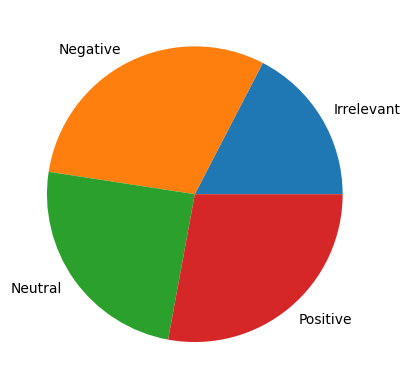

In [35]:
plt.pie(dt['Count'], labels=dt['Value'])
plt.show()

<h2>Appling undersampling</h2>

In [36]:
rus = RandomUnderSampler(random_state=42)
df_train_rus, _ = rus.fit_resample(dataset, dataset['sentiment'])

,Value,Count
0,Irrelevant,12990
1,Negative,12990
2,Neutral,12990
3,Positive,12990


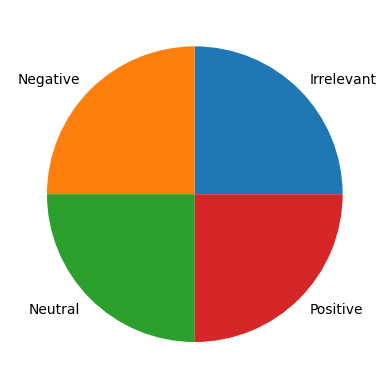

In [37]:
unique_vals, counts = np.unique(df_train_rus['sentiment'], return_counts=True)
dt = pd.DataFrame(zip(unique_vals, counts), columns=['Value', 'Count'])

display(dt)

plt.pie(dt['Count'], labels=dt['Value'])
plt.show()

,Value,Count
0,Irrelevant,22542
1,Negative,22542
2,Neutral,22542
3,Positive,22542


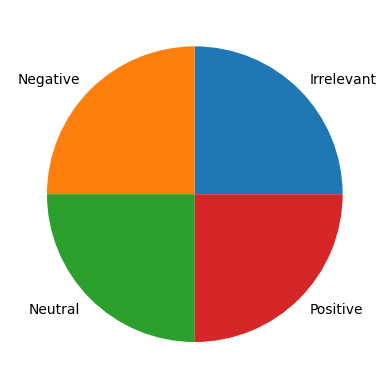

In [38]:
ros = RandomOverSampler(random_state=42)
df_train_ros, _ = ros.fit_resample(dataset, dataset['sentiment'])

unique_vals, counts = np.unique(df_train_ros['sentiment'], return_counts=True)
dt = pd.DataFrame(zip(unique_vals, counts), columns=['Value', 'Count'])

display(dt)

plt.pie(dt['Count'], labels=dt['Value'])
plt.show()

In [48]:
def compute_class_weight(train_y):

    class_list = np.array(list(set(train_y)))
    class_weight_value = sk_weights.compute_class_weight(class_weight ='balanced', classes = class_list, y = train_y)
    class_weight = dict()

    curr_max = int(np.max(class_list))
    for i in range(curr_max):
        class_weight[i] = 1

    for i in range(len(class_list)):
        class_weight[class_list[i]] = class_weight_value[i]

    return class_weight

In [49]:
encoder = LabelEncoder()
dataset['sentiment'] = encoder.fit_transform(dataset['sentiment'])
dataset

,2401,Borderlands,sentiment,text
0,2401,Borderlands,3,I am coming to the borders and I will kill you...
1,2401,Borderlands,3,im getting on borderlands and i will kill you ...
2,2401,Borderlands,3,im coming on borderlands and i will murder you...
3,2401,Borderlands,3,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,3,im getting into borderlands and i can murder y...
...,...,...,...,...
74676,9200,Nvidia,3,Just realized that the Windows partition of my...
74677,9200,Nvidia,3,Just realized that my Mac window partition is ...
74678,9200,Nvidia,3,Just realized the windows partition of my Mac ...
74679,9200,Nvidia,3,Just realized between the windows partition of...


In [53]:
weights = compute_class_weight(dataset['sentiment'])

In [54]:
def weighted_sparse_categorical_crossentropy(weights):
    weights = tf.constant([weights[i] for i in sorted(weights.keys())], dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weight_per_sample = tf.gather(weights, y_true)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return loss * weight_per_sample

    return loss_fn

# Usage
loss_fn = weighted_sparse_categorical_crossentropy(weights)

E0000 00:00:1751817391.411513    1505 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1751817391.416476    1505 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
